In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = (
    pd.read_csv("unclean_smartwatch_health_data.csv")
    #Rename column names to fit Python naming rule
    .rename(columns = lambda col: col.strip().lower().replace(" ", "_").replace("(", "").replace(")", ""))
    #Convert ERROR to NAN using numpy
    .replace("ERROR", np.nan, regex = False).replace("Very High", np.nan, regex = False)
    #Drop null values
    .dropna()
    #Converted String figures to float
    .assign(sleep_duration_hours = lambda x: x["sleep_duration_hours"].astype(float))
    .assign(stress_level = lambda x: x["stress_level"].astype(int))
    .assign(activity_level = lambda x: x["activity_level"].str.replace("_", " ", regex = False).str.replace("Actve", "Active", regex = False)
            .str.replace(r"(.)\1+", r"\1", regex = True))
    #Drop column user id and Stress level because 
    .drop(columns = ["user_id"])
)
df.head()

,heart_rate_bpm,blood_oxygen_level_%,step_count,sleep_duration_hours,activity_level,stress_level
0,58.939776,98.809650,5450.390578,7.167236,Highly Active,1
3,40.000000,96.894213,13797.338044,7.367790,Active,3
5,96.285938,94.202910,10205.992256,8.378343,Highly Active,10
6,47.272257,95.389760,3208.781177,7.871146,Sedentary,2
7,81.733497,95.981343,6051.249857,5.224139,Sedentary,1


In [16]:
numeric_cols = ["heart_rate_bpm","blood_oxygen_level_%", "step_count", "sleep_duration_hours", "stress_level"]

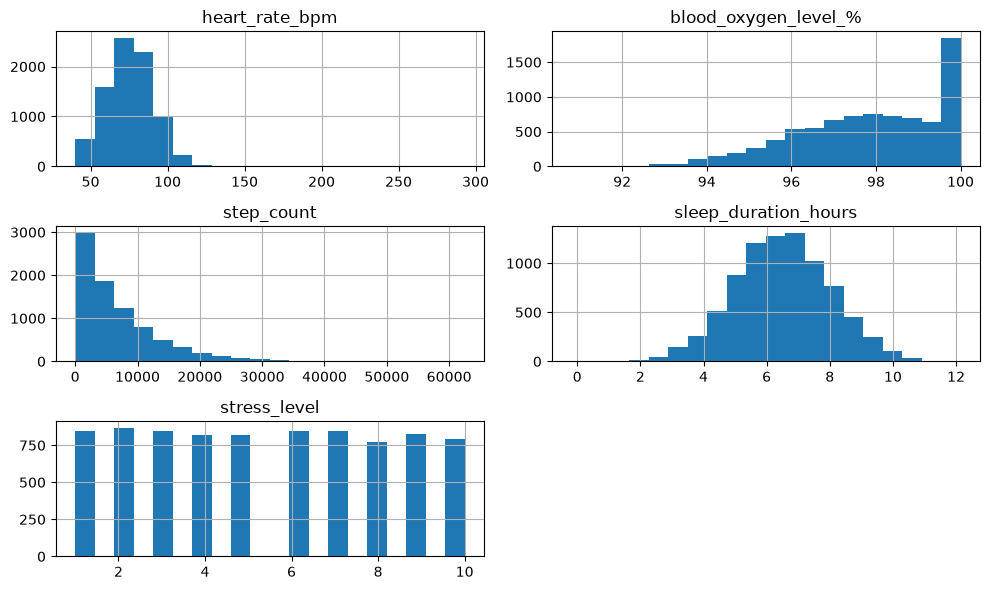

In [25]:
#Create histograms for each of the variables

df[numeric_cols].hist(figsize = (10, 6), bins = 20)
plt.tight_layout()
plt.show();

In [ ]:
print(df["stress_level"].nunique())
#The stress_level column will be kept because nunique > 1. It equals 10 and counts are almost equal)

10
